In [14]:
# ------------------------------------------------------------------------------
# 1. SETUP & IMPORTS
# ------------------------------------------------------------------------------
import os
import datetime as dt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib  # For Model Persistence
from mpl_toolkits.mplot3d import Axes3D

# Scikit-Learn libraries for Machine Learning
from sklearn.preprocessing import PowerTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest

# Set visual theme for presentation-ready charts
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.max_open_warning': 0, 'figure.figsize': (10, 6)})

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
# ------------------------------------------------------------------------------
# 2. DIRECTORY MANAGEMENT
# ------------------------------------------------------------------------------
BASE_DIR = '/content/drive/MyDrive/DAC3'
DATA_PATH = os.path.join(BASE_DIR, 'Data', 'Online Retail.xlsx')
OUTPUT_DIR = os.path.join(BASE_DIR, 'Output')

# Subdirectories specifically tailored for artifact generation
SUBDIRS = {
    'charts': os.path.join(OUTPUT_DIR, 'Charts'),
    'metrics': os.path.join(OUTPUT_DIR, 'Metrics'),
    'models': os.path.join(OUTPUT_DIR, 'Models'),
    'data': os.path.join(OUTPUT_DIR, 'Data')
}

for path in SUBDIRS.values():
    os.makedirs(path, exist_ok=True)

In [19]:
# ------------------------------------------------------------------------------
# 3. DATA LOADING & EXPLORATION (CLEANING)
# ------------------------------------------------------------------------------
print("Loading dataset from Excel...")
df = pd.read_excel(DATA_PATH)

# Remove missing IDs, cancelled orders ('C'), and negative values
df_clean = df.dropna(subset=['CustomerID']).copy()
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]

# Calculate Total Amount per line item
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

Loading dataset from Excel...


In [20]:
# ------------------------------------------------------------------------------
# 4. RFM FEATURE ENGINEERING (Named Aggregation & Date Handling)
# ------------------------------------------------------------------------------
print("Engineering features using Named Aggregation...")

# Date Handling Trick: Study ends 09/12/2011. Set study date one day later.
# This ensures customers who bought on the final day have Recency=1 (not 0),
# preventing log(0) errors downstream.
study_date = dt.datetime(2011, 12, 10)

# Modern Pandas "Named Aggregation" for clean, flat column names right out of the box
rfm = df_clean.groupby('CustomerID').agg(
    LastTransaction=('InvoiceDate', 'max'),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary_Sum=('TotalAmount', 'sum'),
    Monetary_Min=('TotalAmount', 'min'),
    Monetary_Max=('TotalAmount', 'max'),
    Monetary_Median=('TotalAmount', 'median')
).reset_index()

# Recency Calculation in Days, then converted to Months
rfm['Recency_Days'] = (study_date - rfm['LastTransaction']).dt.days
rfm['Recency_Months'] = np.round(rfm['Recency_Days'] / 30.44, 2)

# Define core features for modeling
clustering_cols = ['Recency_Months', 'Frequency', 'Monetary_Sum']


Engineering features using Named Aggregation...


In [21]:
# ------------------------------------------------------------------------------
# 5. OUTLIER ISOLATION & MODEL PERSISTENCE
# ------------------------------------------------------------------------------
print("Isolating outliers using Isolation Forest...")

iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
rfm['Outlier_Flag'] = iso_forest.fit_predict(rfm[clustering_cols])

# Save the Isolation Forest model for production
joblib.dump(iso_forest, os.path.join(SUBDIRS['models'], 'isolation_forest_model.pkl'))

outliers_df = rfm[rfm['Outlier_Flag'] == -1].copy()
rfm_clean = rfm[rfm['Outlier_Flag'] == 1].copy()

outliers_df.to_csv(os.path.join(SUBDIRS['data'], 'Isolated_Outliers.csv'), index=False)

Isolating outliers using Isolation Forest...


In [22]:
# ------------------------------------------------------------------------------
# 6. NORMALIZATION: YEO-JOHNSON POWER TRANSFORMER
# ------------------------------------------------------------------------------
print("Applying Yeo-Johnson PowerTransformer...")

# Yeo-Johnson automatically handles heavy right-skewed data and performs zero-mean,
# unit-variance standardization all in one step.
pt = PowerTransformer(method='yeo-johnson')
rfm_scaled_array = pt.fit_transform(rfm_clean[clustering_cols])
rfm_scaled = pd.DataFrame(rfm_scaled_array, index=rfm_clean.index, columns=clustering_cols)

# Save the PowerTransformer model for production inference
joblib.dump(pt, os.path.join(SUBDIRS['models'], 'power_transformer_model.pkl'))


Applying Yeo-Johnson PowerTransformer...


['/content/drive/MyDrive/DAC3/Output/Models/power_transformer_model.pkl']

In [23]:
# ------------------------------------------------------------------------------
# 7. MODELING & OPTIMAL K
# ------------------------------------------------------------------------------
print("Running K-Means optimizations...")

sse = []
sil_scores = []
k_range = range(2, 9)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    sse.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, kmeans.labels_))

# Hardcoding K=4 based on standard retail heuristics and silhouette peaks
optimal_k = 4
best_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm_clean['Cluster'] = best_kmeans.fit_predict(rfm_scaled)

# Save the final K-Means model for production
joblib.dump(best_kmeans, os.path.join(SUBDIRS['models'], 'kmeans_final_model.pkl'))

Running K-Means optimizations...


['/content/drive/MyDrive/DAC3/Output/Models/kmeans_final_model.pkl']

In [24]:
# ------------------------------------------------------------------------------
# 8. DYNAMIC CENTROID SORTING (Cluster Profiling Logic)
# ------------------------------------------------------------------------------
# We calculate the mathematical center of each cluster and sort them strictly
# based on average Monetary value to dynamically assign business names.
print("Applying Dynamic Centroid Sorting...")

cluster_centers = rfm_clean.groupby('Cluster')[['Monetary_Sum']].mean()
sorted_clusters = cluster_centers.sort_values(by='Monetary_Sum').index

segment_map = {
    sorted_clusters[0]: 'Lost / Low Value',
    sorted_clusters[1]: 'At Risk / Occasional',
    sorted_clusters[2]: 'Recent / Potential Loyal',
    sorted_clusters[3]: 'Champions / Loyal'
}
rfm_clean['Segment_Name'] = rfm_clean['Cluster'].map(segment_map)

# Custom Hex Colors explicitly mapped to specific string names for consistency
CUSTOM_COLORS = {
    'Lost / Low Value': '#e74c3c',         # Flat Red
    'At Risk / Occasional': '#f39c12',     # Flat Orange
    'Recent / Potential Loyal': '#3498db', # Flat Blue
    'Champions / Loyal': '#2ecc71'         # Flat Green
}
# Create an ordered list of keys for consistent plotting
SEGMENT_ORDER = ['Lost / Low Value', 'At Risk / Occasional', 'Recent / Potential Loyal', 'Champions / Loyal']

Applying Dynamic Centroid Sorting...


In [28]:
# ------------------------------------------------------------------------------
# 9. ADVANCED METRICS EXTRACTION (.csv Focus)
# ------------------------------------------------------------------------------
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

print("Generating and exporting metrics...")

# Basic Statistics per Segment
cluster_stats = rfm_clean.groupby('Segment_Name').agg({
    'Recency_Months': ['min', 'max', 'median'],
    'Frequency': ['min', 'max', 'median'],
    'Monetary_Sum': ['min', 'max', 'median', 'sum'],
    'CustomerID': 'count'
}).reset_index()

cluster_stats.columns = [
    'Segment', 'R_Min', 'R_Max', 'R_Median', 'F_Min', 'F_Max', 'F_Median',
    'M_Min', 'M_Max', 'M_Median', 'Total_Revenue', 'Customer_Count'
]

# Advanced Business Metrics: Market Share & Average Order Value (AOV)
total_customers = len(rfm_clean)
cluster_stats['Market_Share_Pct'] = np.round((cluster_stats['Customer_Count'] / total_customers) * 100, 2)
cluster_stats['Revenue_Share_Pct'] = np.round((cluster_stats['Total_Revenue'] / cluster_stats['Total_Revenue'].sum()) * 100, 2)
cluster_stats['Avg_Customer_LTV'] = np.round(cluster_stats['Total_Revenue'] / cluster_stats['Customer_Count'], 2)

# Sort the stats dataframe logically based on our predefined order
cluster_stats['Segment'] = pd.Categorical(cluster_stats['Segment'], categories=SEGMENT_ORDER, ordered=True)
cluster_stats = cluster_stats.sort_values('Segment')

# ---------------------------------------------------------
# NEW: Unsupervised Machine Learning Evaluation Metrics
# ---------------------------------------------------------
# Calculate advanced clustering validation metrics
sil_score_final = silhouette_score(rfm_scaled, rfm_clean['Cluster'])
db_index = davies_bouldin_score(rfm_scaled, rfm_clean['Cluster'])
ch_index = calinski_harabasz_score(rfm_scaled, rfm_clean['Cluster'])

# Create a DataFrame for the ML Metrics
ml_metrics = pd.DataFrame({
    'Metric': ['Silhouette Score', 'Davies-Bouldin Index', 'Calinski-Harabasz Index'],
    'Value': [np.round(sil_score_final, 4), np.round(db_index, 4), np.round(ch_index, 4)],
    'Interpretation': ['Higher is better (Closer to 1)', 'Lower is better', 'Higher is better']
})

# Export Metrics to CSV
cluster_stats.to_csv(os.path.join(SUBDIRS['metrics'], 'Advanced_Cluster_Statistics.csv'), index=False)
ml_metrics.to_csv(os.path.join(SUBDIRS['metrics'], 'Unsupervised_ML_Evaluation_Metrics.csv'), index=False)
rfm_clean.to_csv(os.path.join(SUBDIRS['data'], 'Final_Segmented_Customers.csv'), index=False)

print("\n--- ADVANCED BUSINESS METRICS ---")
display(cluster_stats)

print("\n--- UNSUPERVISED ML EVALUATION METRICS ---")
display(ml_metrics)

Generating and exporting metrics...

--- ADVANCED BUSINESS METRICS ---


,Segment,R_Min,R_Max,R_Median,F_Min,F_Max,F_Median,M_Min,M_Max,M_Median,Total_Revenue,Customer_Count,Market_Share_Pct,Revenue_Share_Pct,Avg_Customer_LTV
2,Lost / Low Value,1.68,12.25,7.23,1,6,1.0,3.75,1542.08,237.610,296567.961,1053,25.55,6.10,281.64
0,At Risk / Occasional,0.00,2.83,0.92,1,7,1.0,6.90,2328.84,346.120,372380.140,931,22.59,7.66,399.98
3,Recent / Potential Loyal,0.69,10.35,2.79,1,9,3.0,167.50,6207.67,898.685,1051827.902,938,22.76,21.63,1121.35
1,Champions / Loyal,0.00,3.25,0.49,1,21,6.0,306.72,12669.98,2085.080,3142192.760,1199,29.09,64.61,2620.68



--- UNSUPERVISED ML EVALUATION METRICS ---


,Metric,Value,Interpretation
0,Silhouette Score,0.3629,Higher is better (Closer to 1)
1,Davies-Bouldin Index,0.9818,Lower is better
2,Calinski-Harabasz Index,3713.3878,Higher is better



Generating, saving, and displaying charts...


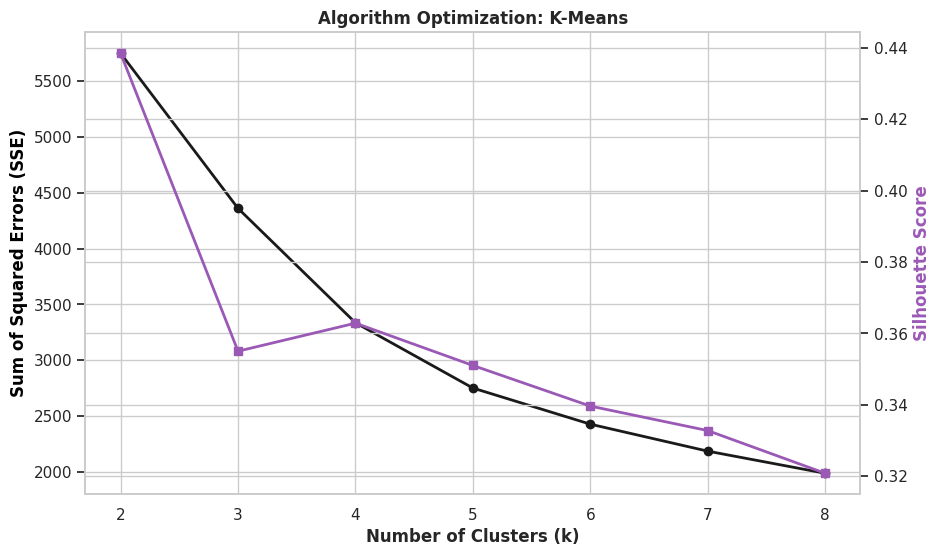

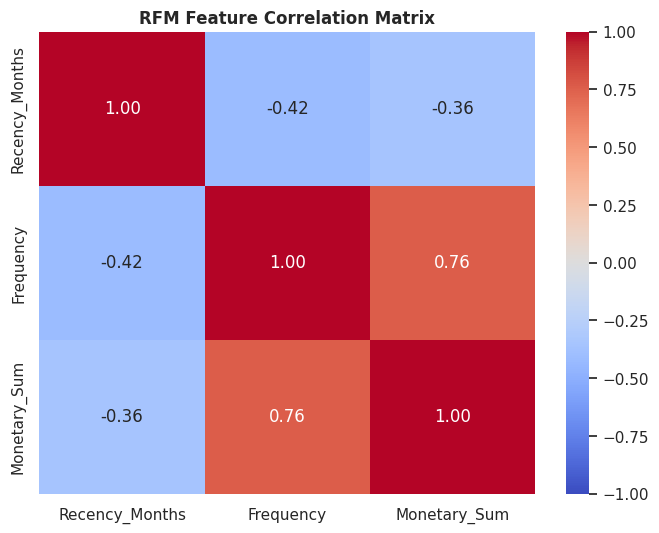

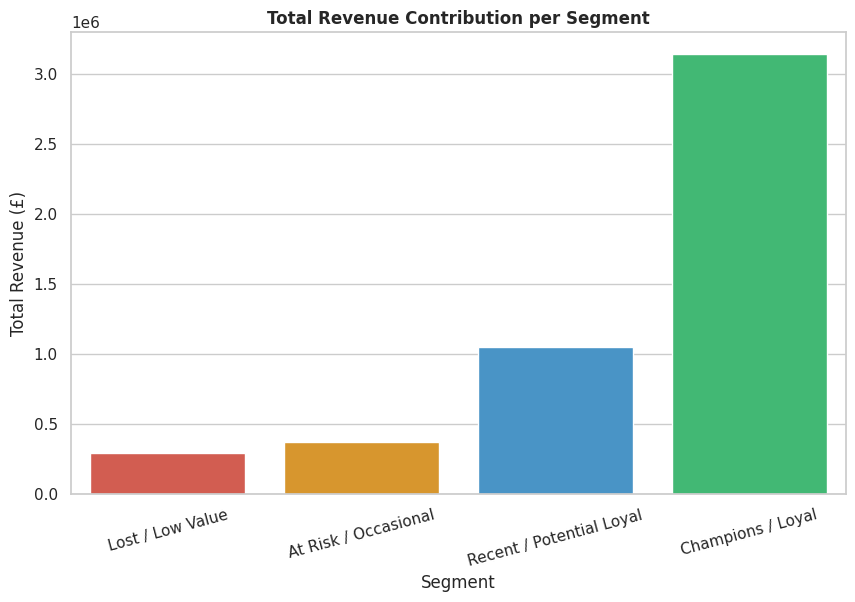

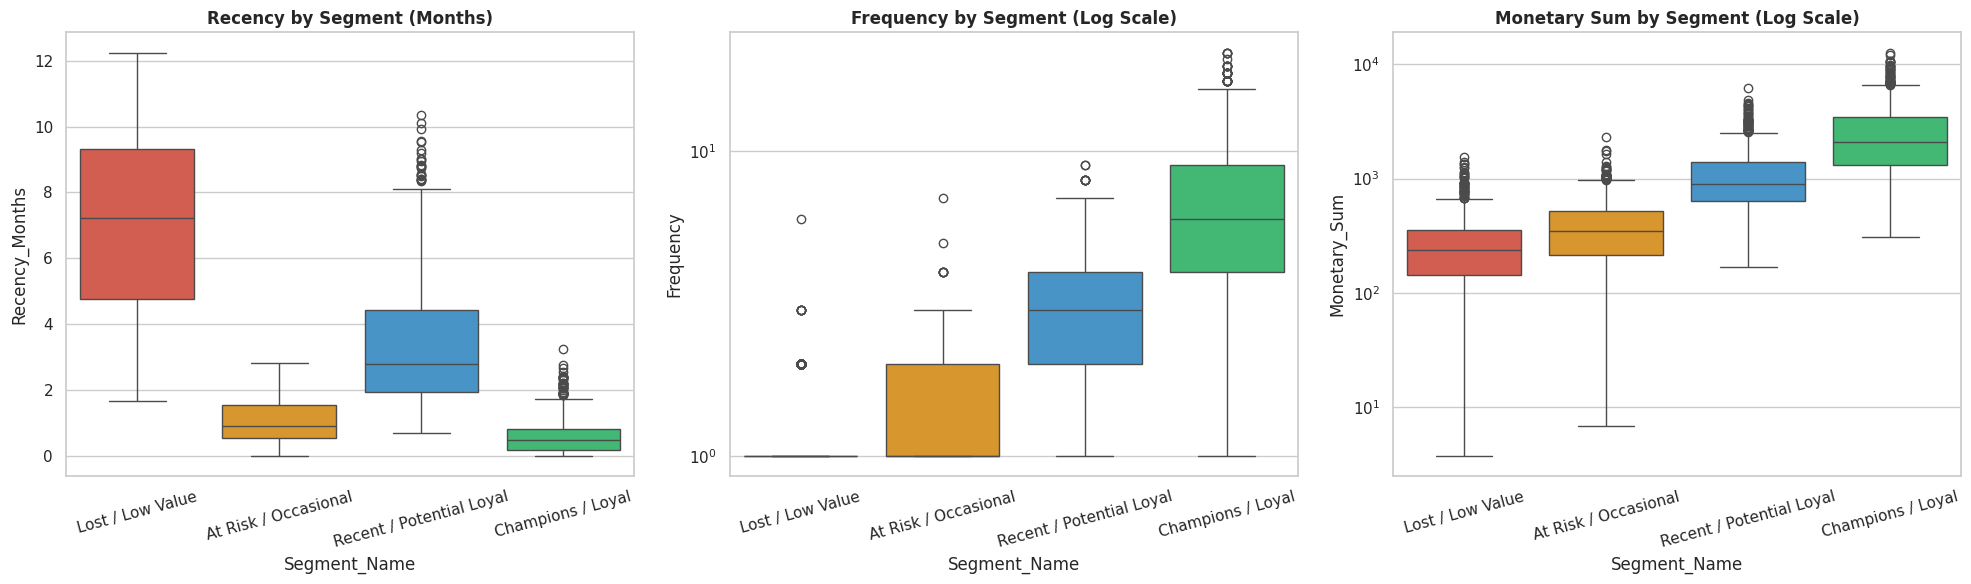

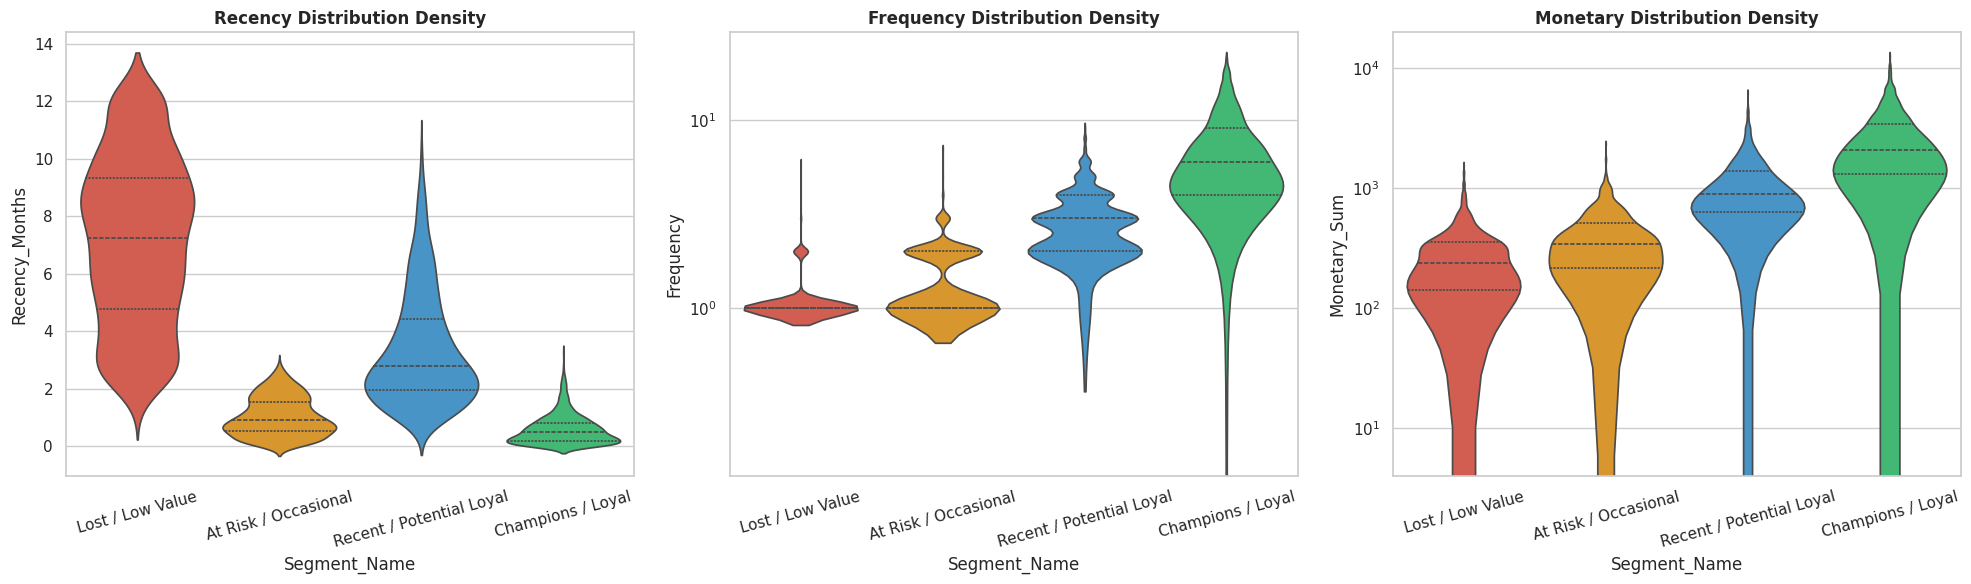

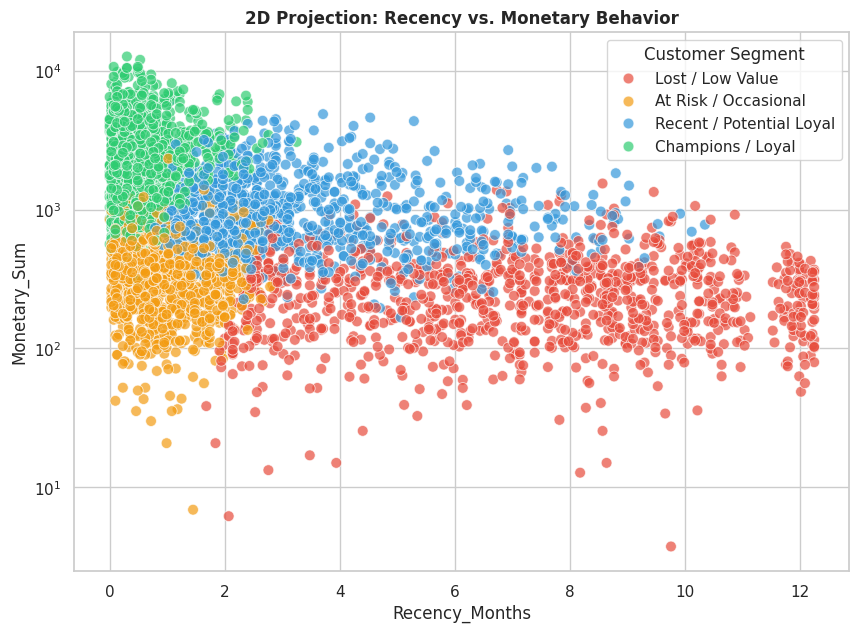

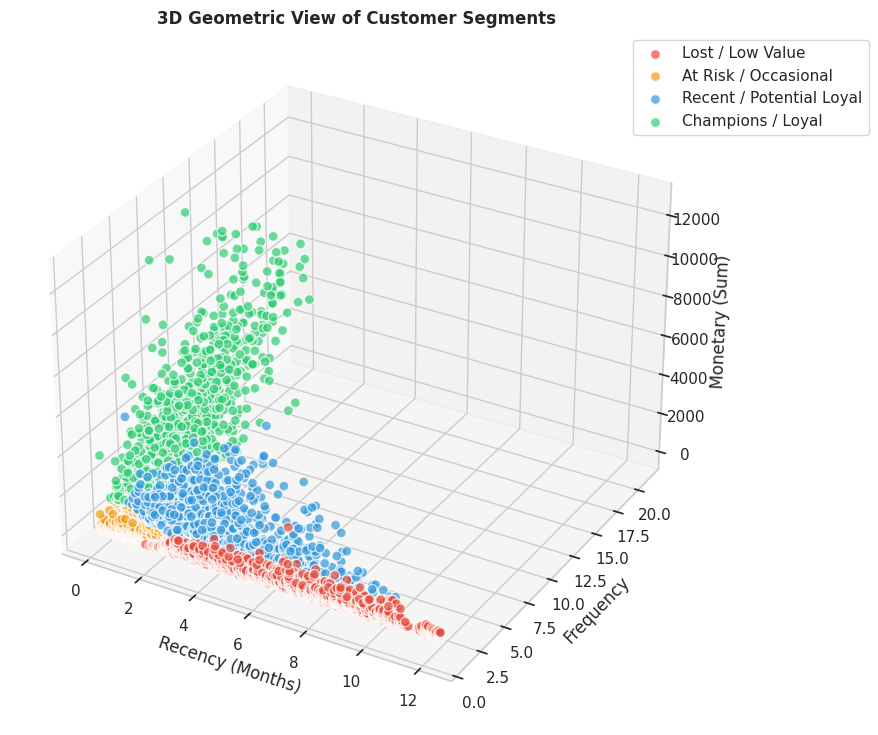

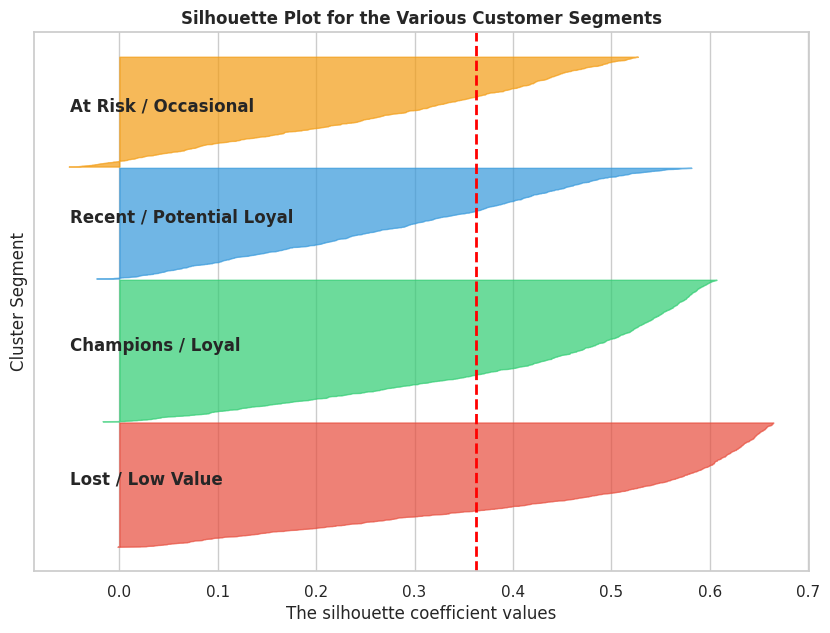


✅ Pipeline Complete! All CSVs, Charts, and PKL models saved to /content/drive/MyDrive/DAC3/Output.


In [31]:
# ------------------------------------------------------------------------------
# 10. VISUAL ANALYTICS (Strict Color Mapping & Display Outputs)
# ------------------------------------------------------------------------------
print("\nGenerating, saving, and displaying charts...")

# --- CHART 1: Elbow & Silhouette Optimization ---
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(k_range, sse, 'ko-', linewidth=2, label='SSE')
ax1.set_xlabel('Number of Clusters (k)', fontweight='bold')
ax1.set_ylabel('Sum of Squared Errors (SSE)', color='black', fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(k_range, sil_scores, 's-', color='#9b59b6', linewidth=2, label='Silhouette')
ax2.set_ylabel('Silhouette Score', color='#9b59b6', fontweight='bold')
plt.title('Algorithm Optimization: K-Means', fontweight='bold')
plt.savefig(os.path.join(SUBDIRS['charts'], 'Elbow_Silhouette_Curve.png'), dpi=300, bbox_inches='tight')
plt.show() # Display in Colab output

# --- CHART 2: Correlation Heatmap ---
plt.figure(figsize=(8, 6))
sns.heatmap(rfm_clean[['Recency_Months', 'Frequency', 'Monetary_Sum']].corr(),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('RFM Feature Correlation Matrix', fontweight='bold')
plt.savefig(os.path.join(SUBDIRS['charts'], 'Feature_Correlation_Heatmap.png'), dpi=300, bbox_inches='tight')
plt.show() # Display in Colab output

# --- CHART 3: Total Revenue Contribution by Segment (Bar Chart) ---
plt.figure(figsize=(10, 6))
sns.barplot(x='Segment', y='Total_Revenue', data=cluster_stats, palette=CUSTOM_COLORS, order=SEGMENT_ORDER, hue='Segment', legend=False)
plt.title('Total Revenue Contribution per Segment', fontweight='bold')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=15)
plt.savefig(os.path.join(SUBDIRS['charts'], 'Revenue_Contribution_Bar.png'), dpi=300, bbox_inches='tight')
plt.show() # Display in Colab output

# --- CHART 4: RFM Boxplots (Strict Custom Colors) ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.boxplot(x='Segment_Name', y='Recency_Months', data=rfm_clean, ax=axes[0], palette=CUSTOM_COLORS, order=SEGMENT_ORDER, hue='Segment_Name', legend=False)
axes[0].set_title('Recency by Segment (Months)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

sns.boxplot(x='Segment_Name', y='Frequency', data=rfm_clean, ax=axes[1], palette=CUSTOM_COLORS, order=SEGMENT_ORDER, hue='Segment_Name', legend=False)
axes[1].set_title('Frequency by Segment (Log Scale)', fontweight='bold')
axes[1].set_yscale('log')
axes[1].tick_params(axis='x', rotation=15)

sns.boxplot(x='Segment_Name', y='Monetary_Sum', data=rfm_clean, ax=axes[2], palette=CUSTOM_COLORS, order=SEGMENT_ORDER, hue='Segment_Name', legend=False)
axes[2].set_title('Monetary Sum by Segment (Log Scale)', fontweight='bold')
axes[2].set_yscale('log')
axes[2].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(SUBDIRS['charts'], 'RFM_Boxplots.png'), dpi=300, bbox_inches='tight')
plt.show() # Display in Colab output

# --- CHART 5: RFM Violin Plots (Distribution Density) ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.violinplot(x='Segment_Name', y='Recency_Months', data=rfm_clean, ax=axes[0], palette=CUSTOM_COLORS, order=SEGMENT_ORDER, inner="quartile", hue='Segment_Name', legend=False)
axes[0].set_title('Recency Distribution Density', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

sns.violinplot(x='Segment_Name', y='Frequency', data=rfm_clean, ax=axes[1], palette=CUSTOM_COLORS, order=SEGMENT_ORDER, inner="quartile", hue='Segment_Name', legend=False)
axes[1].set_title('Frequency Distribution Density', fontweight='bold')
axes[1].set_yscale('log')
axes[1].tick_params(axis='x', rotation=15)

sns.violinplot(x='Segment_Name', y='Monetary_Sum', data=rfm_clean, ax=axes[2], palette=CUSTOM_COLORS, order=SEGMENT_ORDER, inner="quartile", hue='Segment_Name', legend=False)
axes[2].set_title('Monetary Distribution Density', fontweight='bold')
axes[2].set_yscale('log')
axes[2].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(SUBDIRS['charts'], 'RFM_Violin_Plots.png'), dpi=300, bbox_inches='tight')
plt.show() # Display in Colab output

# --- CHART 6: 2D Recency vs Monetary Scatter ---
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Recency_Months', y='Monetary_Sum', hue='Segment_Name',
                data=rfm_clean, palette=CUSTOM_COLORS, hue_order=SEGMENT_ORDER, alpha=0.7, s=60)
plt.title('2D Projection: Recency vs. Monetary Behavior', fontweight='bold')
plt.yscale('log')
plt.legend(title='Customer Segment')
plt.savefig(os.path.join(SUBDIRS['charts'], '2D_Scatter_Recency_Monetary.png'), dpi=300, bbox_inches='tight')
plt.show() # Display in Colab output

# --- CHART 7: 3D Scatter Plot (Strict Custom Colors) ---
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

for segment in SEGMENT_ORDER:
    subset = rfm_clean[rfm_clean['Segment_Name'] == segment]
    ax.scatter(subset['Recency_Months'],
               subset['Frequency'],
               subset['Monetary_Sum'],
               c=CUSTOM_COLORS[segment], label=segment, alpha=0.7, edgecolors='w', s=50)

ax.set_xlabel('Recency (Months)')
ax.set_ylabel('Frequency')
ax.set_zlabel('Monetary (Sum)')
ax.set_title('3D Geometric View of Customer Segments', fontweight='bold')
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
plt.savefig(os.path.join(SUBDIRS['charts'], '3D_Cluster_Scatter.png'), dpi=300, bbox_inches='tight')
plt.show() # Display in Colab output

# --- CHART 8: Individual Cluster Silhouette Plot (The K-Means "Accuracy" equivalent) ---
from sklearn.metrics import silhouette_samples
import matplotlib.cm as cm

fig, ax1 = plt.subplots(1, 1, figsize=(10, 7))

# Get silhouette scores for every individual customer
sample_silhouette_values = silhouette_samples(rfm_scaled, rfm_clean['Cluster'])
y_lower = 10

for i in range(optimal_k):
    # Aggregate the silhouette scores for samples belonging to cluster i, and sort them
    ith_cluster_silhouette_values = sample_silhouette_values[rfm_clean['Cluster'] == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    # Map the cluster ID to our exact custom colors
    segment_name = [k for k, v in segment_map.items() if k == i][0] # Find the mapped name
    color = CUSTOM_COLORS[segment_map[i]]

    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)

    # Label the silhouette plots with their cluster numbers at the middle
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(segment_map[i]), fontweight='bold')
    y_lower = y_upper + 10  # 10 for the 0 samples

ax1.set_title("Silhouette Plot for the Various Customer Segments", fontweight='bold')
ax1.set_xlabel("The silhouette coefficient values")
ax1.set_ylabel("Cluster Segment")

# The vertical line for average silhouette score of all the values
ax1.axvline(x=sil_score_final, color="red", linestyle="--", linewidth=2)
ax1.set_yticks([])  # Clear the yaxis labels / ticks

plt.savefig(os.path.join(SUBDIRS['charts'], 'Silhouette_Distribution_Plot.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✅ Pipeline Complete! All CSVs, Charts, and PKL models saved to {OUTPUT_DIR}.")